# Is Bitcoin Digital Gold?

**A regime-aware test of purchasing power, inflation sensitivity,
safe-haven behavior, and gold-like market exposures**

*Status: Draft 1 · fixed sample through 27 July 2026 · educational
research, not investment advice*

## tl;dr

- **Bitcoin preserved purchasing power, but by a very different path
  from gold.** It produced a positive annualized real return in 98.7% of
  rolling five-year windows, while experiencing 66.0% annualized
  volatility and an -83.0% maximum drawdown.
- **The inflation-hedge result was inconclusive.** A one-standard-
  deviation increase in the notebook's inflation-shock proxy was
  associated with a +0.56 percentage-point BTC monthly return, but the
  moving-block interval was wide at [-2.83, +3.74] percentage points.
- **Bitcoin was not a safe haven during equity stress.** On the worst 5%
  of SPY days, BTC returned -2.61% on average, with a wholly negative
  resampled interval and a 1.66 stress beta to SPY. GLD averaged +0.12%.
- **Market behavior was more Nasdaq-like than gold-like.** Median
  24-month correlation was 0.34 with QQQ versus 0.13 with GLD, and BTC's
  standardized factor fingerprint was closer to QQQ.
- A trailing-risk-matched BTC sleeve raised historical CAGR slightly
  relative to SPY, but did not reproduce the gold sleeve's lower
  volatility, shallower drawdown, or higher Sharpe ratio.

**Draft verdict:** Over this sample, "digital gold" describes Bitcoin's
scarcity narrative and retrospective appreciation better than its
observed defensive market function. The evidence is more consistent
with a high-risk, time-varying diversifier than a reliable substitute
for gold.

## Context & Methods

"Digital gold" is not one empirical claim. This notebook separates it
into four testable dimensions:

1. **Store of value:** Did BTC preserve purchasing power over rolling
   three- and five-year holding periods?
2. **Inflation hedge:** Did BTC respond positively to inflation shocks
   after accounting for equity returns, real yields, and the US dollar?
3. **Safe haven:** Did BTC hold value during the worst 5% of S&P 500
   trading days?
4. **Gold-like behavior:** Were BTC's macro and market exposures closer
   to gold or to the Nasdaq-100?

The notebook compares BTC with `GLD` as an investable gold proxy and
`QQQ` as a risk-asset alternative. `SPY` defines equity-market stress.

### Pre-specified hypotheses

- **H1:** BTC has positive long-horizon real returns, but materially
  higher volatility and drawdowns than gold.
- **H2:** BTC returns respond positively and consistently to the
  notebook's inflation-shock proxy.
- **H3:** BTC's average return is non-negative and its equity beta is
  near zero or negative during severe equity down days.
- **H4:** BTC's standardized factor exposures are closer to GLD than to
  QQQ.
- **H5:** A small, trailing-volatility-matched BTC sleeve provides
  portfolio behavior comparable with a 10% gold sleeve.

### Key assumptions

- The analysis uses adjusted USD closes and simple returns.
- Daily cross-asset tests use only shared US trading dates. Weekend BTC
  observations are not forward-filled into ETF return calculations.
- CPI is monthly. Purchasing-power and inflation tests therefore use
  month-end returns rather than mixing monthly macro data with daily
  returns.
- The inflation-shock proxy is monthly CPI inflation minus its trailing
  12-month mean known at the prior month. It is **not** a professional
  survey-based measure of unexpected inflation.
- The worst 5% of SPY days are selected mechanically from the full
  sample, avoiding hand-picked crisis dates.
- Regression intervals use a six-month moving-block bootstrap with a
  fixed random seed. They describe sampling uncertainty in this
  historical window, not future uncertainty.
- The risk-matched BTC sleeve uses only trailing 36-month volatility and
  is shifted one month to avoid using current-month information.
- Correlation, regression, and backtests are descriptive. They do not
  establish causality, intrinsic value, or a recommended allocation.

### Research references

- [Bouri et al. (2017), hedge and safe-haven properties of
  Bitcoin](https://doi.org/10.1016/j.frl.2016.09.025)
- [Shahzad et al. (2020), gold versus Bitcoin for G7
  equities](https://doi.org/10.1016/j.econmod.2019.01.023)
- [Chemkha et al. (2021), Bitcoin and gold during
  COVID-19](https://doi.org/10.1016/j.qref.2021.07.006)

## Data

**Market series**

- Yahoo Finance adjusted closes: `BTC-USD`, `SPY`, `QQQ`, `GLD`
- Yahoo Finance close: `^VIX`

**Macroeconomic series from FRED**

- `CPIAUCSL`: US consumer price index
- `DFII10`: 10-year Treasury inflation-indexed security yield
- `DTWEXBGS`: trade-weighted US dollar index, broad

The market snapshot is fixed at 1 January 2015 through 27 July 2026.
FRED files include 2014 history so trailing inflation calculations do not
begin with an empty lookback window. The latest CPI observation in the
local snapshot determines the final month used by monthly tests.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings(
    "ignore",
    message="urllib3 v2 only supports OpenSSL",
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from btc_risk.data import ASSET_COLUMNS, load_market_prices, market_data_quality
from btc_risk.metrics import summary_table

START_DATE = "2015-01-01"
END_DATE = "2026-07-28"  # yfinance end date is exclusive
FRED_START_DATE = "2014-01-01"
FRED_END_DATE = "2026-07-27"
MARKET_CACHE = PROJECT_ROOT / "data" / "raw" / "market_prices_2015_2026.csv"
CPI_CACHE = PROJECT_ROOT / "data" / "raw" / "fred_cpi_2014_2026.csv"
REAL_YIELD_CACHE = (
    PROJECT_ROOT / "data" / "raw" / "fred_real_yield_2014_2026.csv"
)
DOLLAR_CACHE = PROJECT_ROOT / "data" / "raw" / "fred_dollar_2014_2026.csv"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "BTC": "#1549D6",
    "GLD": "#B07C13",
    "QQQ": "#6F6B62",
    "SPY": "#171714",
    "positive": "#227A5B",
    "negative": "#B3453D",
    "light": "#D8D2C6",
}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.edgecolor": COLORS["SPY"],
    "text.color": COLORS["SPY"],
    "axes.labelcolor": COLORS["SPY"],
})

### 1. Load the fixed market and macro snapshots

In [2]:
def load_fred_series(path: Path, series_id: str) -> pd.Series:
    if path.exists():
        frame = pd.read_csv(path, parse_dates=["observation_date"])
    else:
        fred_url = (
            "https://fred.stlouisfed.org/graph/fredgraph.csv"
            f"?id={series_id}"
            f"&cosd={FRED_START_DATE}"
            f"&coed={FRED_END_DATE}"
        )
        frame = pd.read_csv(
            fred_url,
            parse_dates=["observation_date"],
        )
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(path, index=False)
    if series_id not in frame.columns:
        raise ValueError(f"{path.name} does not contain {series_id}.")
    values = pd.to_numeric(frame[series_id], errors="coerce")
    series = pd.Series(
        values.to_numpy(),
        index=pd.DatetimeIndex(frame["observation_date"]),
        name=series_id,
        dtype=float,
    ).dropna()
    if series.empty or series.index.has_duplicates:
        raise ValueError(f"Invalid FRED series: {series_id}.")
    return series.sort_index()


prices = load_market_prices(
    cache_path=MARKET_CACHE,
    start_date=START_DATE,
    end_date=END_DATE,
    refresh=False,
)
cpi = load_fred_series(CPI_CACHE, "CPIAUCSL")
real_yield = load_fred_series(REAL_YIELD_CACHE, "DFII10")
broad_dollar = load_fred_series(DOLLAR_CACHE, "DTWEXBGS")

market_data_quality(prices).assign(
    missing_pct=lambda frame: frame["missing_pct"].mul(100).round(2)
)

,first_observation,last_observation,observations,missing_values,missing_pct
asset,,,,,
BTC,2015-01-01,2026-07-27,4226,0,0.00
SPY,2015-01-02,2026-07-27,2907,1319,31.21
QQQ,2015-01-02,2026-07-27,2907,1319,31.21
GLD,2015-01-02,2026-07-27,2907,1319,31.21
VIX,2015-01-02,2026-07-27,2908,1318,31.19


In [3]:
macro_quality = pd.DataFrame({
    "first_observation": [
        cpi.index.min().date(),
        real_yield.index.min().date(),
        broad_dollar.index.min().date(),
    ],
    "last_observation": [
        cpi.index.max().date(),
        real_yield.index.max().date(),
        broad_dollar.index.max().date(),
    ],
    "observations": [cpi.size, real_yield.size, broad_dollar.size],
    "missing_after_numeric_parse": [0, 0, 0],
}, index=["CPIAUCSL", "DFII10", "DTWEXBGS"])
macro_quality

,first_observation,last_observation,observations,missing_after_numeric_parse
CPIAUCSL,2014-01-01,2026-06-01,149,0
DFII10,2014-01-02,2026-07-27,3142,0
DTWEXBGS,2014-01-02,2026-07-24,3128,0


### 2. Align daily and monthly analysis grains

In [4]:
shared_prices = prices[ASSET_COLUMNS].dropna()
daily_returns = shared_prices.pct_change(fill_method=None).dropna()
aligned_vix = prices["VIX"].reindex(daily_returns.index)

monthly_prices = shared_prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change(fill_method=None)

cpi_monthly = cpi.copy()
cpi_monthly.index = cpi_monthly.index.to_period("M").to_timestamp("M")
cpi_monthly = cpi_monthly[~cpi_monthly.index.duplicated(keep="last")]
monthly_inflation = cpi_monthly.pct_change(fill_method=None).rename(
    "monthly_inflation"
)
inflation_shock = (
    monthly_inflation
    - monthly_inflation.rolling(12, min_periods=12).mean().shift(1)
).rename("inflation_shock")

real_yield_monthly = real_yield.resample("ME").last()
real_yield_change = real_yield_monthly.diff().div(100).rename(
    "real_yield_change"
)
dollar_monthly = broad_dollar.resample("ME").last()
dollar_return = dollar_monthly.pct_change(fill_method=None).rename(
    "dollar_return"
)

macro_monthly = pd.concat(
    [monthly_inflation, inflation_shock, real_yield_change, dollar_return],
    axis=1,
)
monthly_analysis = monthly_returns.join(macro_monthly, how="inner").dropna()

assert daily_returns.index.is_monotonic_increasing
assert not daily_returns.index.has_duplicates
assert not daily_returns.isna().any().any()
assert aligned_vix.notna().all()
assert len(monthly_analysis) >= 100
assert np.isfinite(monthly_analysis.to_numpy()).all()

pd.Series({
    "daily_start": daily_returns.index.min().date(),
    "daily_end": daily_returns.index.max().date(),
    "shared_daily_returns": len(daily_returns),
    "monthly_macro_start": monthly_analysis.index.min().date(),
    "monthly_macro_end": monthly_analysis.index.max().date(),
    "complete_months": len(monthly_analysis),
    "latest_CPI_observation": cpi.index.max().date(),
}, name="alignment_check")

daily_start               2015-01-05
daily_end                 2026-07-27
shared_daily_returns            2906
monthly_macro_start       2015-02-28
monthly_macro_end         2026-06-30
complete_months                  136
latest_CPI_observation    2026-06-01
Name: alignment_check, dtype: object

## Results

### 3. Baseline risk: appreciating is not the same as preserving value

A store of value must be evaluated with both purchasing-power outcomes
and the path taken to reach them. High cumulative returns alone do not
reveal whether an investor could experience an extreme interim loss.

In [5]:
baseline_assets = ["BTC", "GLD", "QQQ"]
daily_summary = summary_table(
    daily_returns[baseline_assets],
    periods_per_year=252,
)
baseline_table = pd.DataFrame({
    "CAGR (%)": daily_summary["cagr"] * 100,
    "Annualized volatility (%)": (
        daily_summary["annualized_volatility"] * 100
    ),
    "Maximum drawdown (%)": daily_summary["max_drawdown"] * 100,
    "Daily expected shortfall 95% (%)": (
        daily_summary["expected_shortfall_95"] * 100
    ),
})
baseline_table.round(2)

,CAGR (%),Annualized volatility (%),Maximum drawdown (%),Daily expected shortfall 95% (%)
BTC,58.48,66.00,-83.04,-9.52
GLD,10.86,16.08,-26.40,-2.35
QQQ,18.69,21.95,-35.12,-3.30


In [6]:
monthly_real_returns = (
    (1 + monthly_returns[baseline_assets])
    .div(1 + monthly_inflation, axis=0)
    .sub(1)
    .dropna()
)


def rolling_real_cagr(returns: pd.Series, months: int) -> pd.Series:
    cumulative = (1 + returns).rolling(months).apply(np.prod, raw=True)
    return cumulative.pow(12 / months).sub(1)


rolling_real = {}
purchasing_power_rows = []
for months in (36, 60):
    for asset in baseline_assets:
        series = rolling_real_cagr(
            monthly_real_returns[asset],
            months,
        ).dropna()
        rolling_real[(asset, months)] = series
        purchasing_power_rows.append({
            "asset": asset,
            "horizon": f"{months // 12}-year",
            "windows": len(series),
            "positive_real_return_windows (%)": (series > 0).mean() * 100,
            "median_real_CAGR (%)": series.median() * 100,
            "worst_real_CAGR (%)": series.min() * 100,
        })

purchasing_power_table = (
    pd.DataFrame(purchasing_power_rows)
    .set_index(["asset", "horizon"])
)
purchasing_power_table.round(2)

,,windows,positive_real_return_windows (%),median_real_CAGR (%),worst_real_CAGR (%)
asset,horizon,,,,
BTC,3-year,101,98.02,57.92,-3.65
GLD,3-year,101,74.26,5.63,-6.44
QQQ,3-year,101,100.00,16.05,2.93
BTC,5-year,77,98.70,54.83,-1.24
GLD,5-year,77,100.00,5.58,0.82
QQQ,5-year,77,100.00,15.09,7.62


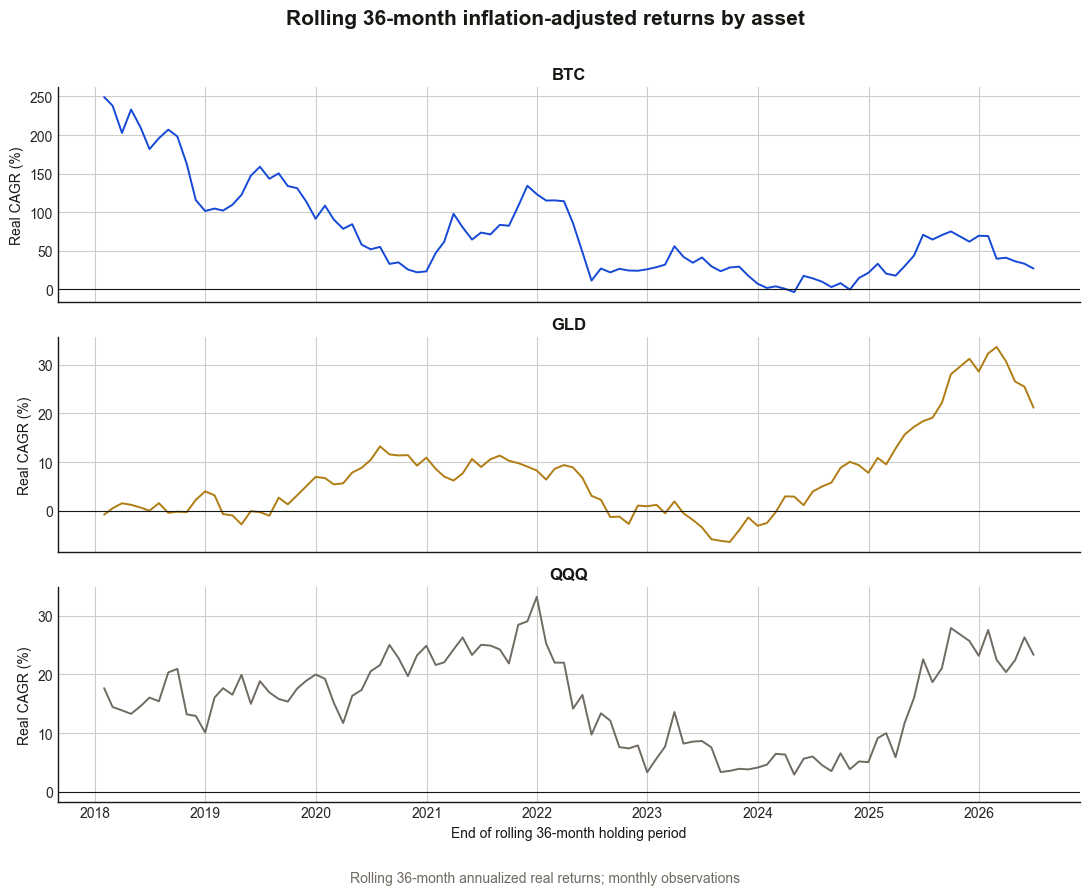

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for axis, asset in zip(axes, baseline_assets):
    series = rolling_real[(asset, 36)].mul(100)
    axis.plot(
        series.index,
        series,
        color=COLORS[asset],
        linewidth=1.4,
    )
    axis.axhline(0, color=COLORS["SPY"], linewidth=0.8)
    axis.set(
        title=asset,
        ylabel="Real CAGR (%)",
    )
axes[-1].set_xlabel("End of rolling 36-month holding period")
fig.suptitle(
    "Rolling 36-month inflation-adjusted returns by asset",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.5,
    0.01,
    "Rolling 36-month annualized real returns; monthly observations",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig(
    FIGURE_DIR / "digital_gold_real_returns.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 4. Inflation sensitivity

Monthly returns are regressed on four standardized factors: SPY return,
the inflation-shock proxy, change in the 10-year real yield, and broad
dollar return. The coefficient below is the percentage-point change in
asset return associated with a one-standard-deviation inflation shock,
holding the other included factors constant.

A positive estimate with an interval above zero would support the
inflation-hedge hypothesis in this sample. An interval spanning zero is
inconclusive.

In [8]:
FACTORS = [
    "SPY",
    "inflation_shock",
    "real_yield_change",
    "dollar_return",
]


def standardized_design(frame: pd.DataFrame, factors: list[str]) -> np.ndarray:
    factor_frame = frame[factors]
    standard_deviations = factor_frame.std(ddof=1)
    if (standard_deviations <= 0).any():
        raise ValueError("All factor columns must have positive variance.")
    standardized = (
        factor_frame - factor_frame.mean()
    ).div(standard_deviations)
    return np.column_stack([np.ones(len(standardized)), standardized])


def ols_coefficients(y: np.ndarray, design: np.ndarray) -> np.ndarray:
    coefficients, _, _, _ = np.linalg.lstsq(design, y, rcond=None)
    return coefficients


def moving_block_indices(
    observations: int,
    block_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    block_count = int(np.ceil(observations / block_size))
    starts = rng.integers(
        0,
        observations - block_size + 1,
        size=block_count,
    )
    sampled = np.concatenate([
        np.arange(start, start + block_size)
        for start in starts
    ])
    return sampled[:observations]


def inflation_coefficient_with_interval(
    frame: pd.DataFrame,
    asset: str,
    simulations: int = 2_000,
    block_size: int = 6,
    seed: int = 17,
) -> pd.Series:
    sample = frame[[asset, *FACTORS]].dropna()
    design = standardized_design(sample, FACTORS)
    y = sample[asset].to_numpy(dtype=float)
    observed = ols_coefficients(y, design)
    inflation_position = 1 + FACTORS.index("inflation_shock")

    rng = np.random.default_rng(seed)
    draws = np.empty(simulations)
    for simulation in range(simulations):
        indices = moving_block_indices(len(sample), block_size, rng)
        draws[simulation] = ols_coefficients(
            y[indices],
            design[indices],
        )[inflation_position]

    lower, upper = np.quantile(draws, [0.025, 0.975])
    return pd.Series({
        "months": len(sample),
        "coefficient_pct_points": (
            observed[inflation_position] * 100
        ),
        "bootstrap_2.5%": lower * 100,
        "bootstrap_97.5%": upper * 100,
    })


inflation_results = pd.DataFrame({
    asset: inflation_coefficient_with_interval(
        monthly_analysis,
        asset,
        seed=17 + position,
    )
    for position, asset in enumerate(baseline_assets)
}).T
inflation_results.round(3)

,months,coefficient_pct_points,bootstrap_2.5%,bootstrap_97.5%
BTC,136.0,0.564,-2.827,3.735
GLD,136.0,-0.220,-0.906,0.236
QQQ,136.0,-0.078,-0.495,0.285


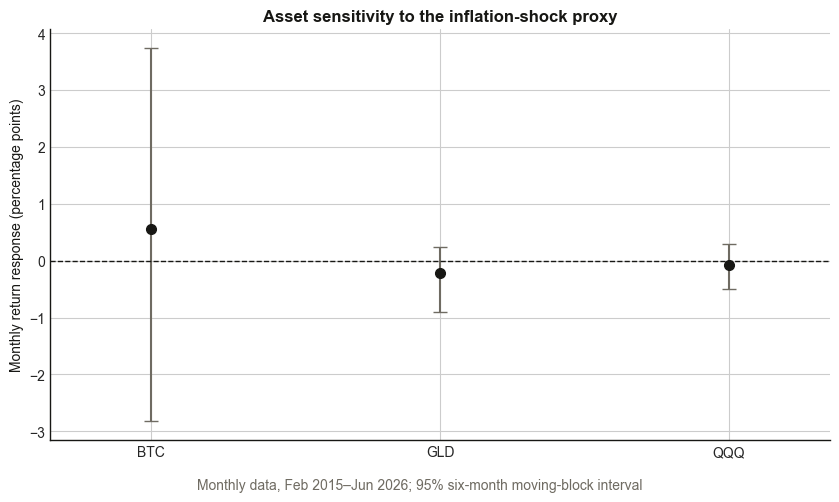

In [9]:
plot_frame = inflation_results.loc[baseline_assets]
estimates = plot_frame["coefficient_pct_points"]
lower_errors = estimates - plot_frame["bootstrap_2.5%"]
upper_errors = plot_frame["bootstrap_97.5%"] - estimates

fig, axis = plt.subplots(figsize=(8.5, 5))
x_positions = np.arange(len(plot_frame))
axis.errorbar(
    x=x_positions,
    y=estimates.to_numpy(dtype=float),
    yerr=np.vstack([
        lower_errors.to_numpy(dtype=float),
        upper_errors.to_numpy(dtype=float),
    ]),
    fmt="o",
    color=COLORS["SPY"],
    ecolor=COLORS["QQQ"],
    capsize=5,
    markersize=7,
)
axis.axhline(0, color=COLORS["SPY"], linewidth=1, linestyle="--")
axis.set(
    title="Asset sensitivity to the inflation-shock proxy",
    ylabel="Monthly return response (percentage points)",
)
axis.set_xticks(x_positions)
axis.set_xticklabels(plot_frame.index.tolist())
axis.set_xlim(-0.35, len(plot_frame) - 0.65)
fig.text(
    0.5,
    0.01,
    "Monthly data, Feb 2015–Jun 2026; 95% six-month moving-block interval",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    FIGURE_DIR / "digital_gold_inflation_sensitivity.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 5. Safe-haven behavior during equity stress

A diversifier can have low average correlation yet still fail exactly
when protection is most valuable. This test evaluates BTC, GLD, and QQQ
only on the mechanically selected worst 5% of SPY trading days.

In [10]:
stress_cutoff = daily_returns["SPY"].quantile(0.05)
stress_sample = daily_returns.loc[
    daily_returns["SPY"] <= stress_cutoff,
    ["BTC", "GLD", "QQQ", "SPY"],
]


def bootstrap_mean_interval(
    returns: pd.Series,
    simulations: int = 5_000,
    seed: int = 29,
) -> tuple[float, float]:
    values = returns.dropna().to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(
        values,
        size=(simulations, len(values)),
        replace=True,
    )
    means = samples.mean(axis=1)
    lower, upper = np.quantile(means, [0.025, 0.975])
    return float(lower), float(upper)


stress_rows = []
for position, asset in enumerate(baseline_assets):
    asset_returns = stress_sample[asset]
    lower, upper = bootstrap_mean_interval(
        asset_returns,
        seed=29 + position,
    )
    equity_variance = stress_sample["SPY"].var(ddof=1)
    stress_beta = (
        stress_sample[[asset, "SPY"]].cov().loc[asset, "SPY"]
        / equity_variance
    )
    stress_rows.append({
        "asset": asset,
        "stress_days": len(stress_sample),
        "mean_return (%)": asset_returns.mean() * 100,
        "mean_CI_2.5%": lower * 100,
        "mean_CI_97.5%": upper * 100,
        "median_return (%)": asset_returns.median() * 100,
        "positive_day_rate (%)": (asset_returns > 0).mean() * 100,
        "beta_to_SPY_in_stress": stress_beta,
    })

stress_table = pd.DataFrame(stress_rows).set_index("asset")
stress_table.round(3)

,stress_days,mean_return (%),mean_CI_2.5%,mean_CI_97.5%,median_return (%),positive_day_rate (%),beta_to_SPY_in_stress
asset,,,,,,,
BTC,146,-2.608,-3.697,-1.614,-1.995,28.767,1.657
GLD,146,0.124,-0.106,0.353,0.028,50.685,0.236
QQQ,146,-3.101,-3.344,-2.888,-2.930,0.685,0.931


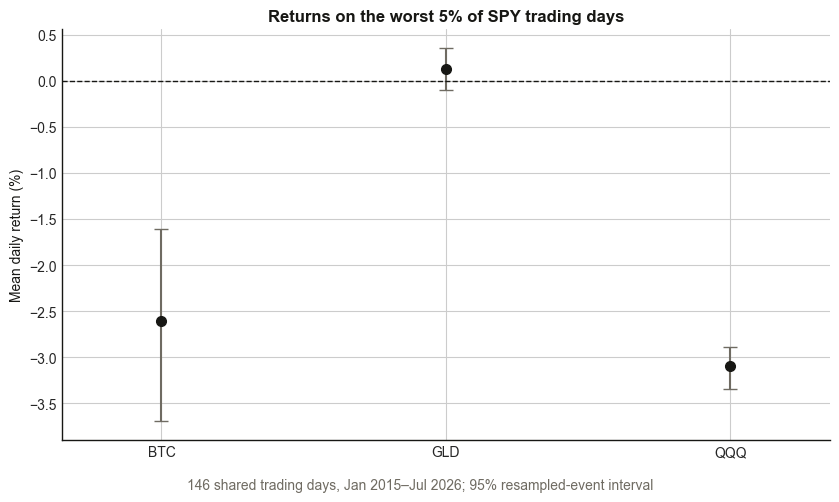

In [11]:
stress_plot = stress_table.loc[baseline_assets]
stress_estimates = stress_plot["mean_return (%)"]
stress_lower = stress_estimates - stress_plot["mean_CI_2.5%"]
stress_upper = stress_plot["mean_CI_97.5%"] - stress_estimates

fig, axis = plt.subplots(figsize=(8.5, 5))
stress_x_positions = np.arange(len(stress_plot))
axis.errorbar(
    x=stress_x_positions,
    y=stress_estimates,
    yerr=np.vstack([stress_lower, stress_upper]),
    fmt="o",
    color=COLORS["SPY"],
    ecolor=COLORS["QQQ"],
    capsize=5,
    markersize=7,
)
axis.axhline(0, color=COLORS["SPY"], linewidth=1, linestyle="--")
axis.set(
    title="Returns on the worst 5% of SPY trading days",
    ylabel="Mean daily return (%)",
)
axis.set_xticks(
    stress_x_positions,
    labels=stress_plot.index.tolist(),
)
axis.set_xlim(-0.35, len(stress_plot) - 0.65)
fig.text(
    0.5,
    0.01,
    "146 shared trading days, Jan 2015–Jul 2026; 95% resampled-event interval",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    FIGURE_DIR / "digital_gold_safe_haven.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 6. Does BTC behave more like gold or Nasdaq?

The first comparison tracks rolling 24-month return correlations. The
second estimates a standardized "factor fingerprint" for each asset.
Standardizing both factors and asset returns makes coefficient patterns
comparable despite BTC's much higher volatility.

Euclidean distance between fingerprints is an intuitive descriptive
summary, not a formal identity test.

In [12]:
rolling_months = 24
rolling_similarity = pd.DataFrame({
    "BTC vs GLD": (
        monthly_returns["BTC"]
        .rolling(rolling_months)
        .corr(monthly_returns["GLD"])
    ),
    "BTC vs QQQ": (
        monthly_returns["BTC"]
        .rolling(rolling_months)
        .corr(monthly_returns["QQQ"])
    ),
}).dropna()

similarity_summary = pd.Series({
    "rolling_windows": len(rolling_similarity),
    "median_BTC_GLD_correlation": (
        rolling_similarity["BTC vs GLD"].median()
    ),
    "median_BTC_QQQ_correlation": (
        rolling_similarity["BTC vs QQQ"].median()
    ),
    "pct_windows_BTC_closer_to_GLD": (
        (
            rolling_similarity["BTC vs GLD"]
            > rolling_similarity["BTC vs QQQ"]
        ).mean()
        * 100
    ),
}, name="24_month_rolling_similarity")
similarity_summary.round(3)

rolling_windows                  115.000
median_BTC_GLD_correlation         0.131
median_BTC_QQQ_correlation         0.339
pct_windows_BTC_closer_to_GLD     26.957
Name: 24_month_rolling_similarity, dtype: float64

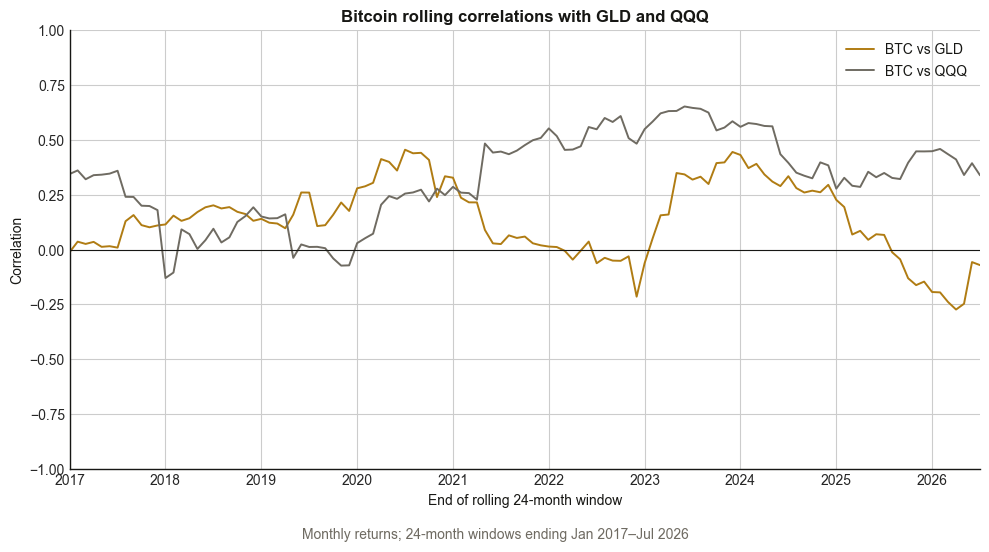

In [13]:
fig, axis = plt.subplots(figsize=(10, 5.5))
rolling_similarity.plot(
    ax=axis,
    color={
        "BTC vs GLD": COLORS["GLD"],
        "BTC vs QQQ": COLORS["QQQ"],
    },
    linewidth=1.4,
)
axis.axhline(0, color=COLORS["SPY"], linewidth=0.8)
axis.set(
    title="Bitcoin rolling correlations with GLD and QQQ",
    xlabel="End of rolling 24-month window",
    ylabel="Correlation",
    ylim=(-1, 1),
)
axis.legend(frameon=False)
fig.text(
    0.5,
    0.01,
    "Monthly returns; 24-month windows ending Jan 2017–Jul 2026",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    FIGURE_DIR / "digital_gold_rolling_similarity.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

In [14]:
factor_labels = {
    "SPY": "Equity",
    "inflation_shock": "Inflation shock",
    "real_yield_change": "Real yield",
    "dollar_return": "US dollar",
}


def standardized_factor_fingerprint(
    frame: pd.DataFrame,
    asset: str,
) -> pd.Series:
    sample = frame[[asset, *FACTORS]].dropna()
    design = standardized_design(sample, FACTORS)
    y = sample[asset]
    standardized_y = (
        (y - y.mean()) / y.std(ddof=1)
    ).to_numpy(dtype=float)
    coefficients = ols_coefficients(standardized_y, design)[1:]
    return pd.Series(
        coefficients,
        index=[factor_labels[factor] for factor in FACTORS],
    )


fingerprints = pd.DataFrame({
    asset: standardized_factor_fingerprint(monthly_analysis, asset)
    for asset in baseline_assets
}).T
btc_to_gld_distance = np.linalg.norm(
    fingerprints.loc["BTC"] - fingerprints.loc["GLD"]
)
btc_to_qqq_distance = np.linalg.norm(
    fingerprints.loc["BTC"] - fingerprints.loc["QQQ"]
)
fingerprint_distances = pd.Series({
    "BTC distance to GLD": btc_to_gld_distance,
    "BTC distance to QQQ": btc_to_qqq_distance,
    "BTC closer to": (
        "GLD"
        if btc_to_gld_distance < btc_to_qqq_distance
        else "QQQ"
    ),
}, name="standardized_factor_fingerprint")

display(fingerprints.round(3))
fingerprint_distances

,Equity,Inflation shock,Real yield,US dollar
BTC,0.332,0.026,-0.086,0.058
GLD,-0.343,-0.049,-0.391,-0.477
QQQ,0.925,-0.014,-0.077,0.073


BTC distance to GLD    0.917013
BTC distance to QQQ    0.595214
BTC closer to               QQQ
Name: standardized_factor_fingerprint, dtype: object

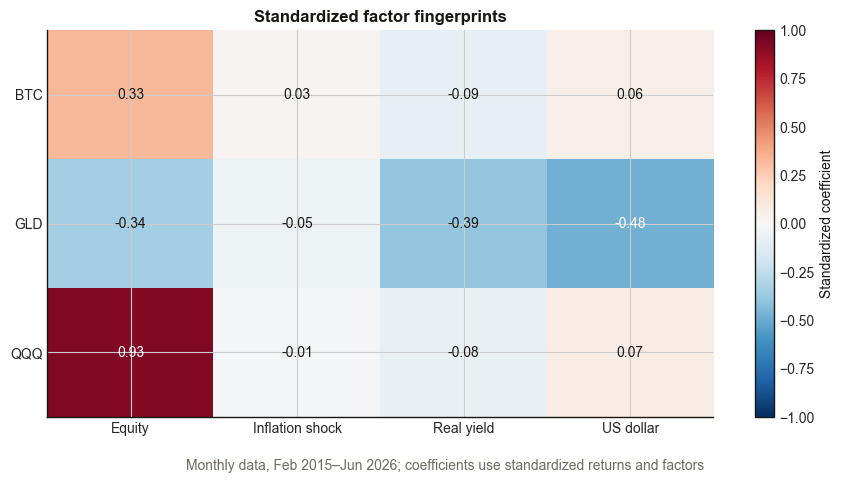

In [15]:
fig, axis = plt.subplots(figsize=(9, 4.8))
image = axis.imshow(
    fingerprints.to_numpy(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
)
axis.set(
    title="Standardized factor fingerprints",
    xticks=np.arange(len(fingerprints.columns)),
    xticklabels=fingerprints.columns,
    yticks=np.arange(len(fingerprints.index)),
    yticklabels=fingerprints.index,
)
for row in range(len(fingerprints.index)):
    for column in range(len(fingerprints.columns)):
        value = fingerprints.iloc[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.45 else COLORS["SPY"],
        )
fig.colorbar(image, ax=axis, label="Standardized coefficient")
fig.text(
    0.5,
    0.01,
    "Monthly data, Feb 2015–Jun 2026; coefficients use standardized returns and factors",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(
    FIGURE_DIR / "digital_gold_factor_fingerprints.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 7. Portfolio comparison at a similar standalone risk budget

A 10% BTC allocation and a 10% gold allocation are not comparable
because BTC is far more volatile. The BTC sleeve below is scaled each
month so that its trailing standalone volatility contribution matches a
10% GLD sleeve, subject to a 10% cap. The remaining weight is allocated
to SPY.

This is an illustrative historical comparison. It excludes trading
costs, taxes, custody, and intramonth rebalancing.

In [16]:
portfolio_source = monthly_returns[["SPY", "GLD", "BTC"]].dropna()
trailing_months = 36
target_gold_weight = 0.10
btc_weight = (
    target_gold_weight
    * portfolio_source["GLD"].rolling(trailing_months).std()
    / portfolio_source["BTC"].rolling(trailing_months).std()
).clip(lower=0, upper=target_gold_weight).shift(1)

portfolio_monthly_returns = pd.DataFrame({
    "SPY 100%": portfolio_source["SPY"],
    "SPY 90% + GLD 10%": (
        0.90 * portfolio_source["SPY"]
        + 0.10 * portfolio_source["GLD"]
    ),
    "SPY + risk-matched BTC": (
        (1 - btc_weight) * portfolio_source["SPY"]
        + btc_weight * portfolio_source["BTC"]
    ),
}).dropna()

portfolio_summary = summary_table(
    portfolio_monthly_returns,
    periods_per_year=12,
)
portfolio_table = pd.DataFrame({
    "CAGR (%)": portfolio_summary["cagr"] * 100,
    "Annualized volatility (%)": (
        portfolio_summary["annualized_volatility"] * 100
    ),
    "Sharpe (rf=0)": portfolio_summary["sharpe_rf_0"],
    "Month-end maximum drawdown (%)": (
        portfolio_summary["max_drawdown"] * 100
    ),
    "Monthly expected shortfall 95% (%)": (
        portfolio_summary["expected_shortfall_95"] * 100
    ),
})

pd.Series({
    "comparison_start": portfolio_monthly_returns.index.min().date(),
    "comparison_end": portfolio_monthly_returns.index.max().date(),
    "months": len(portfolio_monthly_returns),
    "median_BTC_weight_pct": (
        btc_weight.loc[portfolio_monthly_returns.index].median() * 100
    ),
    "maximum_BTC_weight_pct": (
        btc_weight.loc[portfolio_monthly_returns.index].max() * 100
    ),
}, name="risk_matching")

comparison_start          2018-02-28
comparison_end            2026-07-31
months                           102
median_BTC_weight_pct        1.84646
maximum_BTC_weight_pct      3.577319
Name: risk_matching, dtype: object

In [17]:
portfolio_table.round(2)

,CAGR (%),Annualized volatility (%),Sharpe (rf=0),Month-end maximum drawdown (%),Monthly expected shortfall 95% (%)
SPY 100%,13.74,16.45,0.87,-23.93,-9.25
SPY 90% + GLD 10%,13.94,15.10,0.94,-22.46,-8.36
SPY + risk-matched BTC,14.10,16.69,0.88,-24.63,-9.36


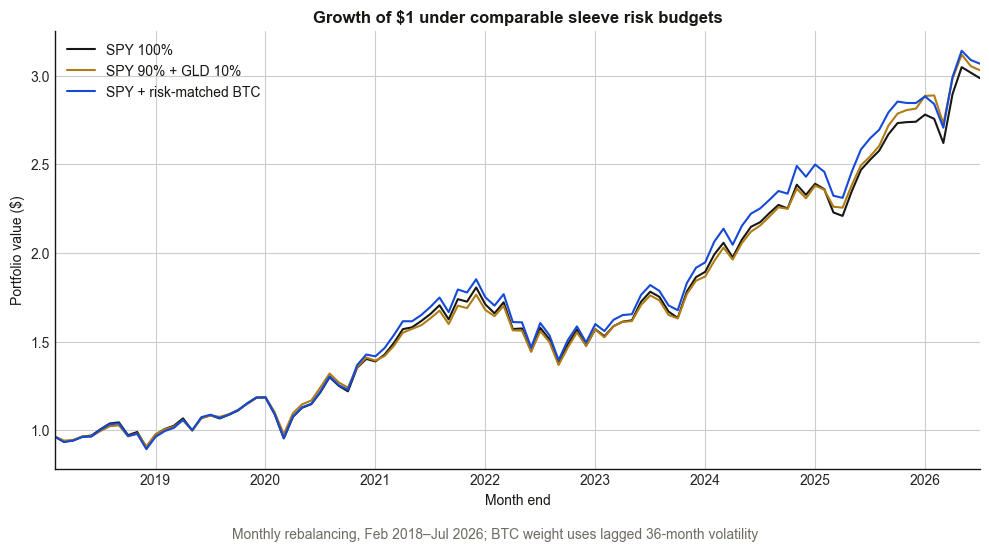

In [18]:
portfolio_wealth = (1 + portfolio_monthly_returns).cumprod()
fig, axis = plt.subplots(figsize=(10, 5.5))
portfolio_wealth.plot(
    ax=axis,
    color={
        "SPY 100%": COLORS["SPY"],
        "SPY 90% + GLD 10%": COLORS["GLD"],
        "SPY + risk-matched BTC": COLORS["BTC"],
    },
    linewidth=1.5,
)
axis.set(
    title="Growth of $1 under comparable sleeve risk budgets",
    xlabel="Month end",
    ylabel="Portfolio value ($)",
)
axis.legend(frameon=False)
fig.text(
    0.5,
    0.01,
    "Monthly rebalancing, Feb 2018–Jul 2026; BTC weight uses lagged 36-month volatility",
    ha="center",
    color=COLORS["QQQ"],
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    FIGURE_DIR / "digital_gold_risk_matched_portfolios.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 8. Auditable facts for the conclusion

In [19]:
key_facts = pd.Series({
    "BTC annualized volatility": (
        daily_summary.loc["BTC", "annualized_volatility"]
    ),
    "GLD annualized volatility": (
        daily_summary.loc["GLD", "annualized_volatility"]
    ),
    "BTC maximum drawdown": (
        daily_summary.loc["BTC", "max_drawdown"]
    ),
    "BTC positive 5-year real windows": (
        purchasing_power_table.loc[
            ("BTC", "5-year"),
            "positive_real_return_windows (%)",
        ] / 100
    ),
    "BTC inflation coefficient": (
        inflation_results.loc["BTC", "coefficient_pct_points"] / 100
    ),
    "BTC inflation CI lower": (
        inflation_results.loc["BTC", "bootstrap_2.5%"] / 100
    ),
    "BTC inflation CI upper": (
        inflation_results.loc["BTC", "bootstrap_97.5%"] / 100
    ),
    "BTC mean return on worst 5% SPY days": (
        stress_table.loc["BTC", "mean_return (%)"] / 100
    ),
    "GLD mean return on worst 5% SPY days": (
        stress_table.loc["GLD", "mean_return (%)"] / 100
    ),
    "BTC stress beta to SPY": (
        stress_table.loc["BTC", "beta_to_SPY_in_stress"]
    ),
    "BTC factor distance to GLD": btc_to_gld_distance,
    "BTC factor distance to QQQ": btc_to_qqq_distance,
    "BTC sleeve median weight": (
        btc_weight.loc[portfolio_monthly_returns.index].median()
    ),
    "SPY-only Sharpe": (
        portfolio_summary.loc["SPY 100%", "sharpe_rf_0"]
    ),
    "Gold-sleeve Sharpe": (
        portfolio_summary.loc[
            "SPY 90% + GLD 10%",
            "sharpe_rf_0",
        ]
    ),
    "Risk-matched BTC-sleeve Sharpe": (
        portfolio_summary.loc[
            "SPY + risk-matched BTC",
            "sharpe_rf_0",
        ]
    ),
}, name="value")
key_facts.round(4)

BTC annualized volatility               0.6600
GLD annualized volatility               0.1608
BTC maximum drawdown                   -0.8304
BTC positive 5-year real windows        0.9870
BTC inflation coefficient               0.0056
BTC inflation CI lower                 -0.0283
BTC inflation CI upper                  0.0374
BTC mean return on worst 5% SPY days   -0.0261
GLD mean return on worst 5% SPY days    0.0012
BTC stress beta to SPY                  1.6571
BTC factor distance to GLD              0.9170
BTC factor distance to QQQ              0.5952
BTC sleeve median weight                0.0185
SPY-only Sharpe                         0.8681
Gold-sleeve Sharpe                      0.9435
Risk-matched BTC-sleeve Sharpe          0.8774
Name: value, dtype: float64

## Takeaways

| Dimension | Draft assessment | Evidence in this sample |
|---|---|---|
| Long-horizon purchasing power | **Strong, but unstable** | 98.7% of rolling five-year real-return windows were positive, alongside an -83.0% maximum drawdown. |
| Inflation hedge | **Inconclusive** | Positive point estimate, but the six-month block-bootstrap interval crossed zero widely. |
| Equity safe haven | **Not supported** | -2.61% mean return and 1.66 SPY beta on the worst 5% of SPY days. |
| Gold-like market behavior | **Mostly not supported** | BTC was closer to QQQ in rolling correlations and standardized factor exposures. |
| Portfolio substitute for gold | **Not supported in downside metrics** | The risk-matched BTC sleeve increased CAGR slightly but had lower Sharpe and worse drawdown than the 10% GLD sleeve. |

The answer therefore depends on the definition. Bitcoin looked like a
powerful long-horizon appreciating asset, but not like a stable
inflation hedge or a crisis-protection asset. Calling it "digital gold"
without specifying the dimension hides this distinction.

### Limitations

- Bitcoin's history is short and structurally changing.
- Yahoo Finance is convenient rather than institutional-grade.
- GLD is an investable proxy, not physical bullion.
- The inflation proxy is backward-looking and is not a survey surprise.
- Daily BTC and ETF closes do not perfectly synchronize their underlying
  market intervals.
- Stress-event bootstrap intervals do not fully model volatility
  clustering.
- The factor fingerprint is descriptive and sensitive to the selected
  factors and sample.
- Historical backtests do not establish future behavior.